# Analisis de Clustering - Fuga de Empleados (sin PCA)

Flujo segun `mermaidPizarra.mmd`:
1. **Categorizar** variables numericas en niveles (Bajo / Medio / Alto)
2. **One-Hot Encoding** de categoricas + categorizadas
3. **Estandarizar** variables numericas con StandardScaler
4. **Clustering**: KModes, Jerarquico y DBSCAN
5. **Seleccion** del mejor metodo
6. **Analisis cualitativo y cuantitativo** de los clusters

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from kmodes.kmodes import KModes
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('dataSet_RRHH.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (4900, 8)


,tenure_years,age,salary_k,performance_score,absenteeism_days,workload_index,Department,Education_Level
0,6.222330,41.652324,52.954657,66.099810,3.494094,8.545036,Finance,PhD
1,12.816358,50.229503,95.905314,94.516390,1.586166,7.587586,Sales,High School
2,7.373974,36.932161,55.760313,66.939439,3.416340,7.239733,IT,High School
3,-1.186950,28.009672,33.047192,55.782684,1.382140,5.927190,Finance,Bachelor
4,1.143603,26.930709,42.245990,91.035230,-0.270007,5.086634,Finance,PhD


## 1. Categorizacion de variables numericas

Dividimos cada variable numerica en 3 niveles (Bajo / Medio / Alto) usando terciles (percentiles 33 y 66). Estas variables categorizadas se usaran para:
- **KModes** (requiere datos categoricos)
- **Analisis cualitativo** final (perfiles de negocio interpretables)

In [19]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numericas: {num_cols}")
print(f"Categoricas: {cat_cols}")

# Categorizar cada variable numerica en Bajo / Medio / Alto (terciles)
df_cat = df.copy()
bins_info = {}

for col in num_cols:
    p33 = df[col].quantile(0.33)
    p66 = df[col].quantile(0.66)
    bins_info[col] = {'p33': round(p33, 2), 'p66': round(p66, 2)}
    
    col_cat = col + '_nivel'
    df_cat[col_cat] = pd.cut(
        df[col],
        bins=[-np.inf, p33, p66, np.inf],
        labels=['Bajo', 'Medio', 'Alto']
    )

print("\nUmbrales de categorizacion:")
for col, vals in bins_info.items():
    print(f"  {col}: Bajo < {vals['p33']} | Medio < {vals['p66']} | Alto >= {vals['p66']}")

# Verificar distribucion
cat_nivel_cols = [c for c in df_cat.columns if c.endswith('_nivel')]
print(f"\nDistribucion de niveles:")
for col in cat_nivel_cols:
    print(f"\n  {col}:")
    print(df_cat[col].value_counts().to_string().replace('\n', '\n    '))

Numericas: ['tenure_years', 'age', 'salary_k', 'performance_score', 'absenteeism_days', 'workload_index']
Categoricas: ['Department', 'Education_Level']

Umbrales de categorizacion:
  tenure_years: Bajo < 4.41 | Medio < 7.68 | Alto >= 7.68
  age: Bajo < 36.73 | Medio < 44.53 | Alto >= 44.53
  salary_k: Bajo < 42.2 | Medio < 63.8 | Alto >= 63.8
  performance_score: Bajo < 47.72 | Medio < 76.63 | Alto >= 76.63
  absenteeism_days: Bajo < 1.96 | Medio < 4.43 | Alto >= 4.43
  workload_index: Bajo < 4.63 | Medio < 6.71 | Alto >= 6.71

Distribucion de niveles:

  tenure_years_nivel:
tenure_years_nivel
    Alto     1666
    Bajo     1617
    Medio    1617

  age_nivel:
age_nivel
    Alto     1666
    Bajo     1617
    Medio    1617

  salary_k_nivel:
salary_k_nivel
    Alto     1666
    Bajo     1617
    Medio    1617

  performance_score_nivel:
performance_score_nivel
    Alto     1666
    Bajo     1617
    Medio    1617

  absenteeism_days_nivel:
absenteeism_days_nivel
    Alto     1666
    

## 2. Preparacion de datasets para clustering

Preparamos dos versiones de los datos:
- **`X_ohe`**: Todas las categoricas (originales + niveles) con one-hot encoding → para **KModes**
- **`X_scaled`**: Numericas escaladas (StandardScaler) + categoricas one-hot → para **KMeans, Jerarquico, DBSCAN**

In [20]:
# --- Dataset para KModes: solo columnas categoricas (originales + niveles) con OHE ---
all_cat_cols = cat_cols + cat_nivel_cols
df_only_cat = df_cat[all_cat_cols].copy()
X_ohe = pd.get_dummies(df_only_cat, drop_first=False, dtype=int)

print(f"X_ohe (para KModes): {X_ohe.shape}")
print(f"  Columnas: {X_ohe.columns.tolist()}")

# --- Dataset para KMeans/Jerarquico/DBSCAN: numericas escaladas + categoricas OHE ---
df_for_scaling = df.copy()
# OHE de las categoricas originales
df_encoded = pd.get_dummies(df_for_scaling, columns=cat_cols, drop_first=True, dtype=int)

scaler = StandardScaler()
# Escalar solo las numericas
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])
X_scaled = df_encoded.copy()

print(f"\nX_scaled (para KMeans/Jerarquico/DBSCAN): {X_scaled.shape}")
print(f"  Columnas: {X_scaled.columns.tolist()}")
print(f"\n  Media numericas (debe ser ~0): {X_scaled[num_cols].mean().round(4).tolist()}")
print(f"  Std numericas (debe ser ~1):  {X_scaled[num_cols].std().round(4).tolist()}")

X_ohe (para KModes): (4900, 27)
  Columnas: ['Department_Finance', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Sales', 'Education_Level_Bachelor', 'Education_Level_High School', 'Education_Level_Master', 'Education_Level_PhD', 'tenure_years_nivel_Bajo', 'tenure_years_nivel_Medio', 'tenure_years_nivel_Alto', 'age_nivel_Bajo', 'age_nivel_Medio', 'age_nivel_Alto', 'salary_k_nivel_Bajo', 'salary_k_nivel_Medio', 'salary_k_nivel_Alto', 'performance_score_nivel_Bajo', 'performance_score_nivel_Medio', 'performance_score_nivel_Alto', 'absenteeism_days_nivel_Bajo', 'absenteeism_days_nivel_Medio', 'absenteeism_days_nivel_Alto', 'workload_index_nivel_Bajo', 'workload_index_nivel_Medio', 'workload_index_nivel_Alto']

X_scaled (para KMeans/Jerarquico/DBSCAN): (4900, 13)
  Columnas: ['tenure_years', 'age', 'salary_k', 'performance_score', 'absenteeism_days', 'workload_index', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Sales', 'Education_Level_High 

---
## 3. Clustering

### 3.1 KModes (datos categoricos)

KModes usa distancia Hamming (numero de atributos que difieren) en lugar de distancia euclidea. Ideal para datos categoricos/binarios. Probamos de 2 a 8 clusters y usamos el **coste** (suma de disimilitudes) para encontrar el codo.

In [21]:
# KModes: busqueda del numero optimo de clusters
K_range = range(2, 9)
kmodes_costs = []
kmodes_models = {}
kmodes_silhouettes = {}

for k in K_range:
    km = KModes(n_clusters=k, init='Cao', n_init=5, random_state=42, verbose=0)
    clusters = km.fit_predict(X_ohe.values)
    kmodes_costs.append(km.cost_)
    kmodes_models[k] = (km, clusters)
    sil = silhouette_score(X_ohe.values, clusters, metric='hamming')
    kmodes_silhouettes[k] = sil
    print(f"  k={k}: coste = {km.cost_:.0f}, silhouette (Hamming) = {sil:.4f}")

  k=2: coste = 34968, silhouette (Hamming) = 0.2133
  k=3: coste = 27845, silhouette (Hamming) = 0.3096
  k=4: coste = 24002, silhouette (Hamming) = 0.3419
  k=5: coste = 21252, silhouette (Hamming) = 0.3772
  k=6: coste = 20344, silhouette (Hamming) = 0.3691
  k=7: coste = 19410, silhouette (Hamming) = 0.3100
  k=8: coste = 19897, silhouette (Hamming) = 0.2565


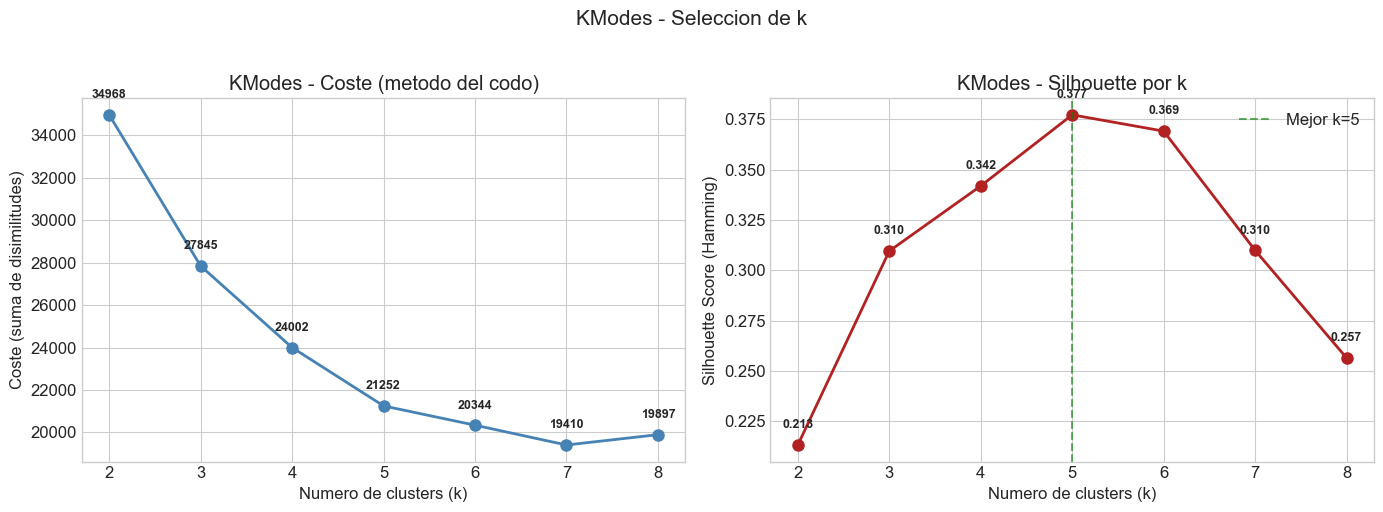

In [22]:
# KModes: graficas de Coste (inercia) y Silhouette por k
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ks = list(K_range)

# Coste (analogo a inercia)
ax1.plot(ks, kmodes_costs, 'o-', linewidth=2, markersize=8, color='steelblue')
for k, cost in zip(ks, kmodes_costs):
    ax1.annotate(f'{cost:.0f}', (k, cost), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Numero de clusters (k)')
ax1.set_ylabel('Coste (suma de disimilitudes)')
ax1.set_title('KModes - Coste (metodo del codo)')
ax1.set_xticks(ks)

# Silhouette
sil_vals = [kmodes_silhouettes[k] for k in ks]
ax2.plot(ks, sil_vals, 'o-', linewidth=2, markersize=8, color='firebrick')
for k, s in zip(ks, sil_vals):
    ax2.annotate(f'{s:.3f}', (k, s), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
best_k_km = ks[np.argmax(sil_vals)]
ax2.axvline(x=best_k_km, color='green', linestyle='--', alpha=0.6, label=f'Mejor k={best_k_km}')
ax2.set_xlabel('Numero de clusters (k)')
ax2.set_ylabel('Silhouette Score (Hamming)')
ax2.set_title('KModes - Silhouette por k')
ax2.set_xticks(ks)
ax2.legend()

plt.suptitle('KModes - Seleccion de k', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

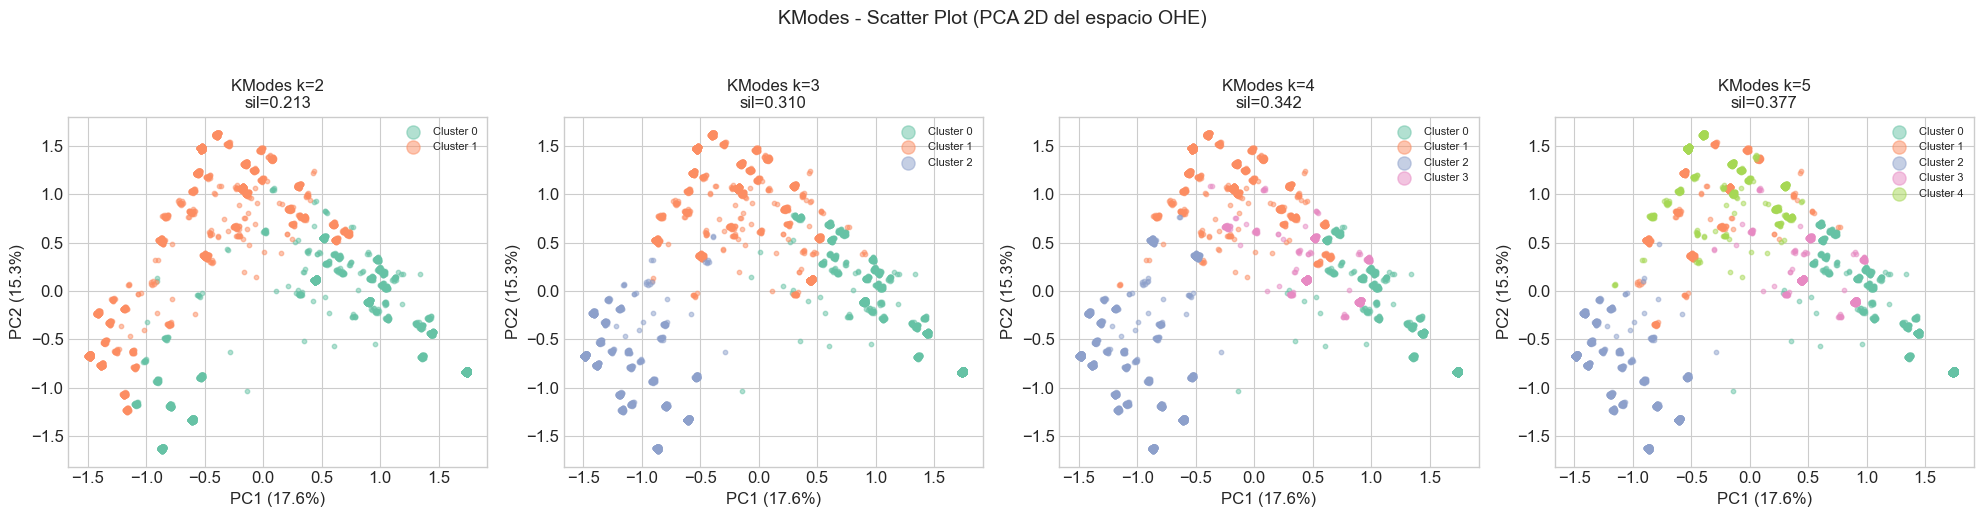

In [23]:
# KModes: scatter plots con PCA 2D para los mejores k
from sklearn.decomposition import PCA

# Proyeccion PCA 2D del espacio OHE (para visualizacion)
pca_2d = PCA(n_components=2)
X_pca_ohe = pca_2d.fit_transform(X_ohe.values)
pca_var = pca_2d.explained_variance_ratio_

# Mostrar scatter para k = 2, 3, 4, 5
ks_to_show = [k for k in [2, 3, 4, 5] if k in kmodes_models]
fig, axes = plt.subplots(1, len(ks_to_show), figsize=(5 * len(ks_to_show), 5))
if len(ks_to_show) == 1:
    axes = [axes]

palette = sns.color_palette('Set2', max(ks_to_show))

for ax, k in zip(axes, ks_to_show):
    _, labels = kmodes_models[k]
    for cl in range(k):
        mask = labels == cl
        ax.scatter(X_pca_ohe[mask, 0], X_pca_ohe[mask, 1],
                   s=10, alpha=0.5, label=f'Cluster {cl}', color=palette[cl])
    ax.set_title(f'KModes k={k}\nsil={kmodes_silhouettes[k]:.3f}', fontsize=12)
    ax.set_xlabel(f'PC1 ({pca_var[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_var[1]*100:.1f}%)')
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle('KModes - Scatter Plot (PCA 2D del espacio OHE)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 3.2 Clustering Jerarquico (Aglomerativo)

Usamos un dendrograma para visualizar la estructura jerarquica y decidir donde cortar. Luego aplicamos `AgglomerativeClustering` con el numero de clusters elegido.

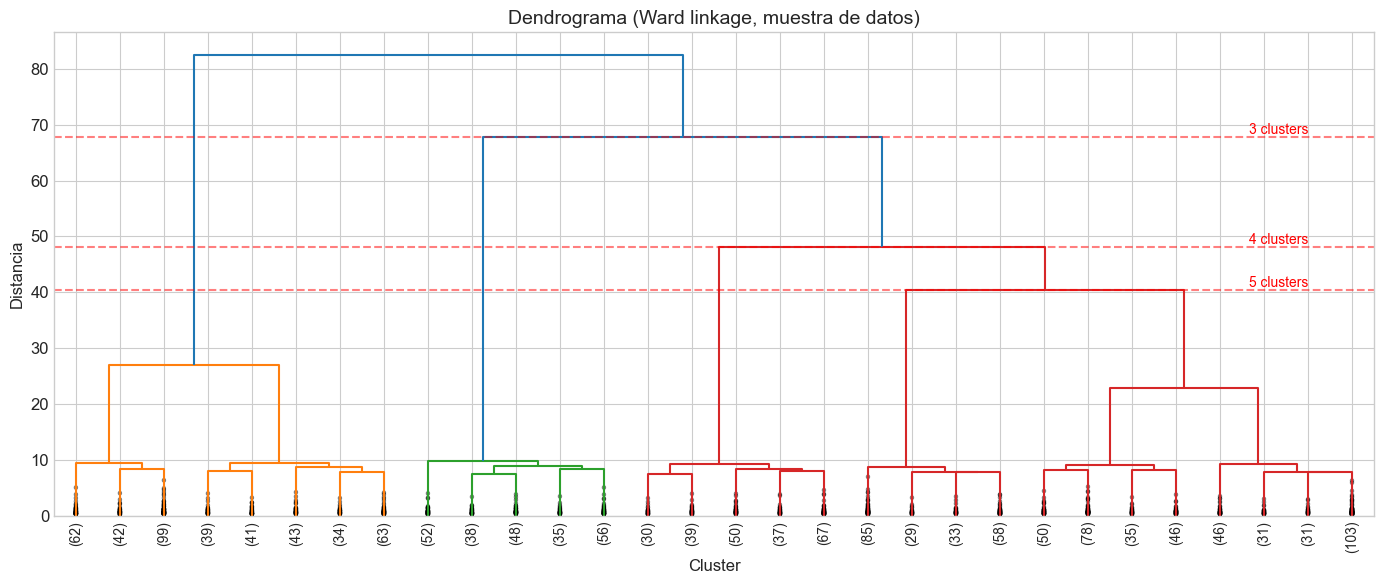

In [24]:
# Dendrograma (sobre muestra si el dataset es grande, para visualizacion)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=min(1500, len(X_scaled)), replace=False)
X_sample = X_scaled.values[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10,
           show_contracted=True, ax=ax)
ax.set_title('Dendrograma (Ward linkage, muestra de datos)', fontsize=14)
ax.set_xlabel('Cluster')
ax.set_ylabel('Distancia')

# Lineas de referencia para posibles cortes
for n_cut in [3, 4, 5]:
    # Distancia aproximada para n_cut clusters
    d = Z[-(n_cut-1), 2]
    ax.axhline(y=d, color='red', linestyle='--', alpha=0.5)
    ax.text(ax.get_xlim()[1]*0.95, d, f'{n_cut} clusters', va='bottom', ha='right', fontsize=10, color='red')

plt.tight_layout()
plt.show()

  k=2: silhouette=0.3121  inercia=24152.2  calinski_harabasz=2264.6  davies_bouldin=1.1807
  k=3: silhouette=0.3610  inercia=16503.5  calinski_harabasz=2791.5  davies_bouldin=1.1697
  k=4: silhouette=0.3708  inercia=13233.7  calinski_harabasz=2723.6  davies_bouldin=1.0196
  k=5: silhouette=0.3520  inercia=10662.6  calinski_harabasz=2829.8  davies_bouldin=1.0960
  k=6: silhouette=0.3269  inercia=9444.2  calinski_harabasz=2681.6  davies_bouldin=1.2064
  k=7: silhouette=0.3079  inercia=8533.6  calinski_harabasz=2559.7  davies_bouldin=1.3701
  k=8: silhouette=0.2882  inercia=8390.4  calinski_harabasz=2242.9  davies_bouldin=1.5172


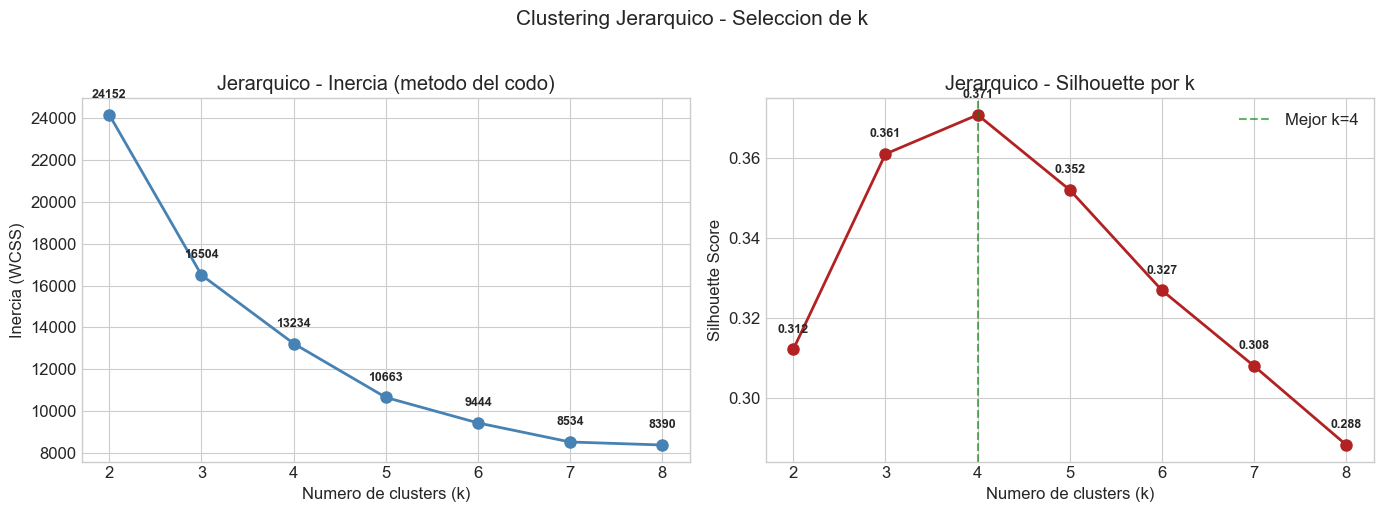

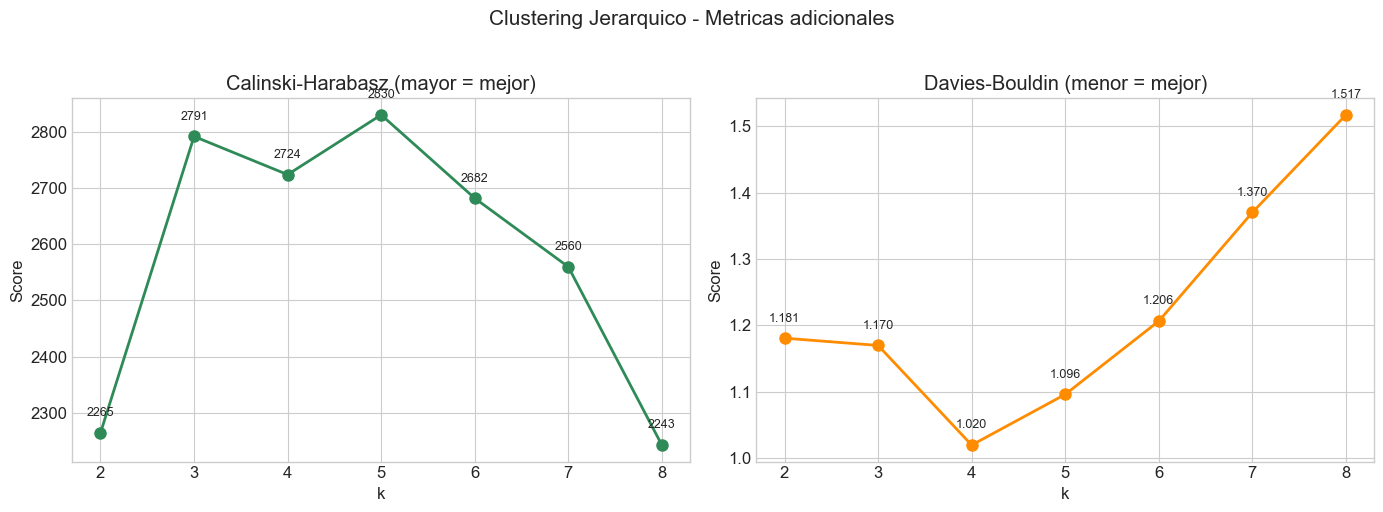

In [25]:
# Jerarquico: metricas para distintos k
# Calculamos tambien la inercia (within-cluster sum of squares) manualmente
hier_scores = {}
hier_inertias = []

for k in K_range:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_scaled.values)
    sil = silhouette_score(X_scaled.values, labels)
    ch = calinski_harabasz_score(X_scaled.values, labels)
    db = davies_bouldin_score(X_scaled.values, labels)
    
    # Inercia: suma de distancias al cuadrado de cada punto a su centroide
    inertia = 0
    for cl in range(k):
        mask = labels == cl
        centroid = X_scaled.values[mask].mean(axis=0)
        inertia += np.sum((X_scaled.values[mask] - centroid) ** 2)
    hier_inertias.append(inertia)
    
    hier_scores[k] = {'silhouette': sil, 'calinski_harabasz': ch, 'davies_bouldin': db, 'labels': labels}
    print(f"  k={k}: silhouette={sil:.4f}  inercia={inertia:.1f}  calinski_harabasz={ch:.1f}  davies_bouldin={db:.4f}")

# --- Graficas: Inercia + Silhouette (las mas importantes) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ks = list(K_range)

# Inercia (codo)
ax1.plot(ks, hier_inertias, 'o-', linewidth=2, markersize=8, color='steelblue')
for k, ine in zip(ks, hier_inertias):
    ax1.annotate(f'{ine:.0f}', (k, ine), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
ax1.set_xlabel('Numero de clusters (k)')
ax1.set_ylabel('Inercia (WCSS)')
ax1.set_title('Jerarquico - Inercia (metodo del codo)')
ax1.set_xticks(ks)

# Silhouette
sil_hier = [hier_scores[k]['silhouette'] for k in ks]
ax2.plot(ks, sil_hier, 'o-', linewidth=2, markersize=8, color='firebrick')
for k, s in zip(ks, sil_hier):
    ax2.annotate(f'{s:.3f}', (k, s), textcoords="offset points",
                 xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
best_k_h = ks[np.argmax(sil_hier)]
ax2.axvline(x=best_k_h, color='green', linestyle='--', alpha=0.6, label=f'Mejor k={best_k_h}')
ax2.set_xlabel('Numero de clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Jerarquico - Silhouette por k')
ax2.set_xticks(ks)
ax2.legend()

plt.suptitle('Clustering Jerarquico - Seleccion de k', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# --- Graficas adicionales: Calinski-Harabasz + Davies-Bouldin ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ks, [hier_scores[k]['calinski_harabasz'] for k in ks], 'o-', linewidth=2, markersize=8, color='seagreen')
for k in ks:
    ax1.annotate(f'{hier_scores[k]["calinski_harabasz"]:.0f}', (k, hier_scores[k]['calinski_harabasz']),
                 textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)
ax1.set_title('Calinski-Harabasz (mayor = mejor)')
ax1.set_xlabel('k'); ax1.set_ylabel('Score'); ax1.set_xticks(ks)

ax2.plot(ks, [hier_scores[k]['davies_bouldin'] for k in ks], 'o-', linewidth=2, markersize=8, color='darkorange')
for k in ks:
    ax2.annotate(f'{hier_scores[k]["davies_bouldin"]:.3f}', (k, hier_scores[k]['davies_bouldin']),
                 textcoords="offset points", xytext=(0, 12), ha='center', fontsize=9)
ax2.set_title('Davies-Bouldin (menor = mejor)')
ax2.set_xlabel('k'); ax2.set_ylabel('Score'); ax2.set_xticks(ks)

plt.suptitle('Clustering Jerarquico - Metricas adicionales', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

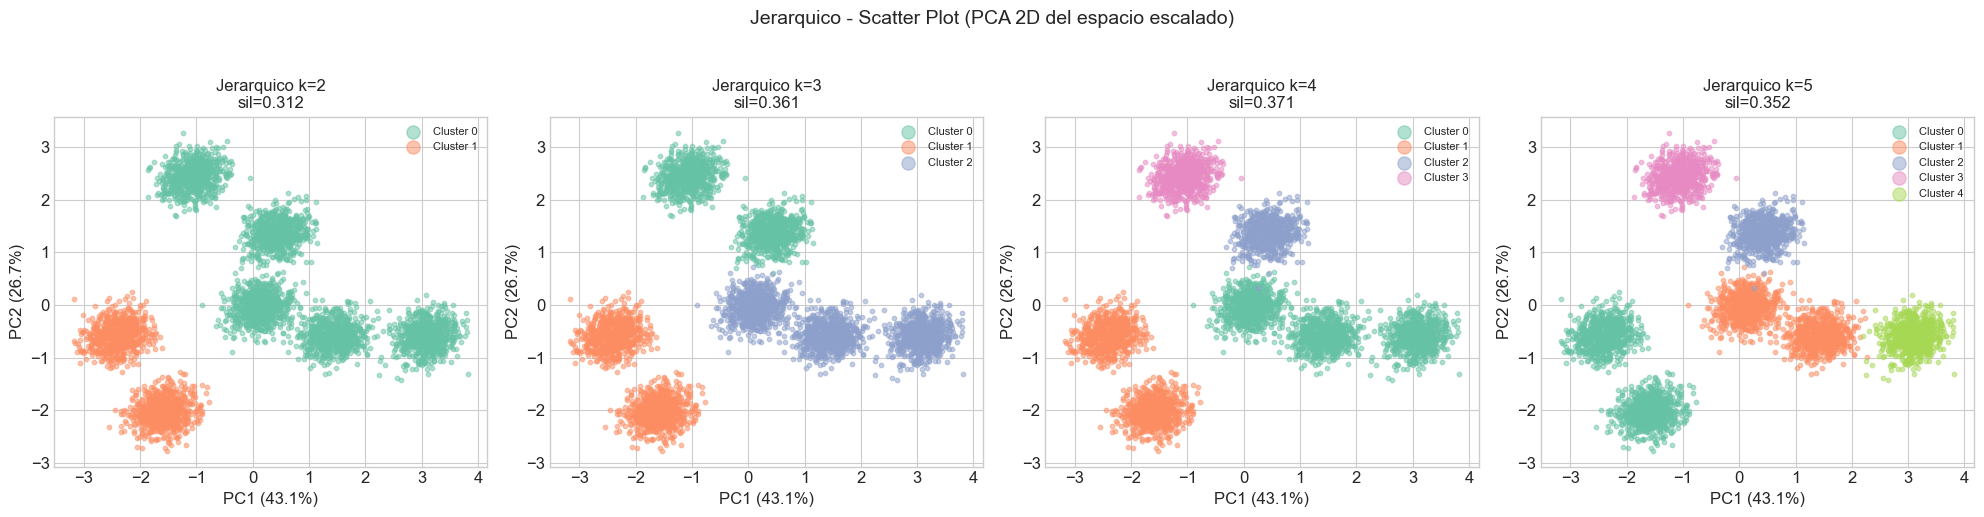

In [26]:
# Jerarquico: scatter plots con PCA 2D
pca_2d_scaled = PCA(n_components=2)
X_pca_scaled = pca_2d_scaled.fit_transform(X_scaled.values)
pca_var_scaled = pca_2d_scaled.explained_variance_ratio_

ks_to_show = [k for k in [2, 3, 4, 5] if k in hier_scores]
fig, axes = plt.subplots(1, len(ks_to_show), figsize=(5 * len(ks_to_show), 5))
if len(ks_to_show) == 1:
    axes = [axes]

palette = sns.color_palette('Set2', max(ks_to_show))

for ax, k in zip(axes, ks_to_show):
    labels = hier_scores[k]['labels']
    for cl in range(k):
        mask = labels == cl
        ax.scatter(X_pca_scaled[mask, 0], X_pca_scaled[mask, 1],
                   s=10, alpha=0.5, label=f'Cluster {cl}', color=palette[cl])
    ax.set_title(f'Jerarquico k={k}\nsil={hier_scores[k]["silhouette"]:.3f}', fontsize=12)
    ax.set_xlabel(f'PC1 ({pca_var_scaled[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_var_scaled[1]*100:.1f}%)')
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle('Jerarquico - Scatter Plot (PCA 2D del espacio escalado)', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

### 3.3 DBSCAN (basado en densidad)

DBSCAN no requiere especificar k, pero necesita dos hiperparametros:
- **eps**: radio maximo de vecindad
- **min_samples**: minimo de puntos para formar un cluster

Usamos el grafico de k-distancias para estimar eps, y probamos varias combinaciones.

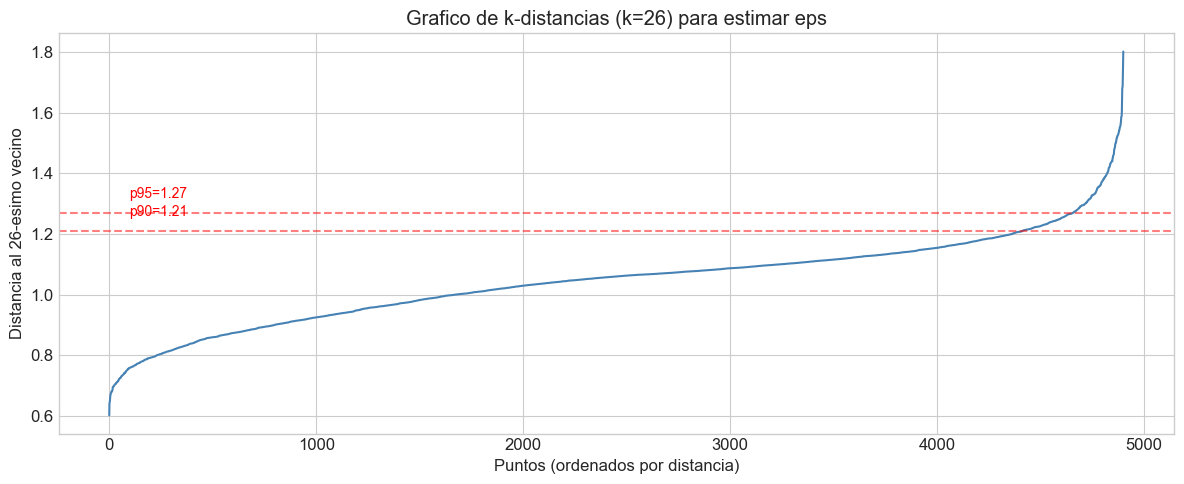


Referencia de percentiles de k-distancias:
  p80 = 1.148
  p85 = 1.174
  p90 = 1.209
  p95 = 1.269


In [27]:
# Grafico de k-distancias para estimar eps
from sklearn.neighbors import NearestNeighbors

k_neighbors = 2 * X_scaled.shape[1]  # regla practica: 2 * n_dims
nn = NearestNeighbors(n_neighbors=k_neighbors)
nn.fit(X_scaled.values)
distances, _ = nn.kneighbors(X_scaled.values)
k_dist = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_dist, linewidth=1.5, color='steelblue')
ax.set_xlabel('Puntos (ordenados por distancia)')
ax.set_ylabel(f'Distancia al {k_neighbors}-esimo vecino')
ax.set_title(f'Grafico de k-distancias (k={k_neighbors}) para estimar eps')

# Marcar zona del codo (percentiles 90-95)
for pct in [90, 95]:
    val = np.percentile(k_dist, pct)
    ax.axhline(y=val, color='red', linestyle='--', alpha=0.5)
    ax.text(len(k_dist)*0.02, val + 0.05, f'p{pct}={val:.2f}', fontsize=10, color='red')

plt.tight_layout()
plt.show()

print(f"\nReferencia de percentiles de k-distancias:")
for p in [80, 85, 90, 95]:
    print(f"  p{p} = {np.percentile(k_dist, p):.3f}")

In [28]:
# DBSCAN: grid search sobre eps y min_samples
eps_values = np.round(np.linspace(
    np.percentile(k_dist, 80),
    np.percentile(k_dist, 97),
    6
), 2)
min_samples_values = [5, 10, 15, 20]

dbscan_results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled.values)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        pct_noise = n_noise / len(labels) * 100
        
        if n_clusters >= 2 and pct_noise < 50:
            sil = silhouette_score(X_scaled.values[labels != -1], labels[labels != -1])
        else:
            sil = -1
        
        dbscan_results.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters, 'n_noise': n_noise,
            'pct_noise': pct_noise, 'silhouette': sil, 'labels': labels
        })

df_dbscan = pd.DataFrame(dbscan_results).drop(columns='labels')
# Mostrar solo combinaciones con al menos 2 clusters
df_valid = df_dbscan[df_dbscan['n_clusters'] >= 2].sort_values('silhouette', ascending=False)
print("Resultados DBSCAN (configuraciones con >= 2 clusters):\n")
print(df_valid.to_string(index=False))

Resultados DBSCAN (configuraciones con >= 2 clusters):

 eps  min_samples  n_clusters  n_noise  pct_noise  silhouette
1.15           20           3        9   0.183673    0.369488
1.18           20           3        6   0.122449    0.369309
1.15           10           3        5   0.102041    0.369304
1.18           10           3        5   0.102041    0.369304
1.18           15           3        5   0.102041    0.369304
1.15           15           3        6   0.122449    0.369285
1.15            5           3        4   0.081633    0.369228
1.22           15           3        4   0.081633    0.369203
1.22           20           3        4   0.081633    0.369203
1.26           20           3        3   0.061224    0.369200
1.26           15           3        3   0.061224    0.369200
1.29           20           3        3   0.061224    0.369200
1.29           15           3        3   0.061224    0.369200
1.22           10           3        3   0.061224    0.369127
1.18          

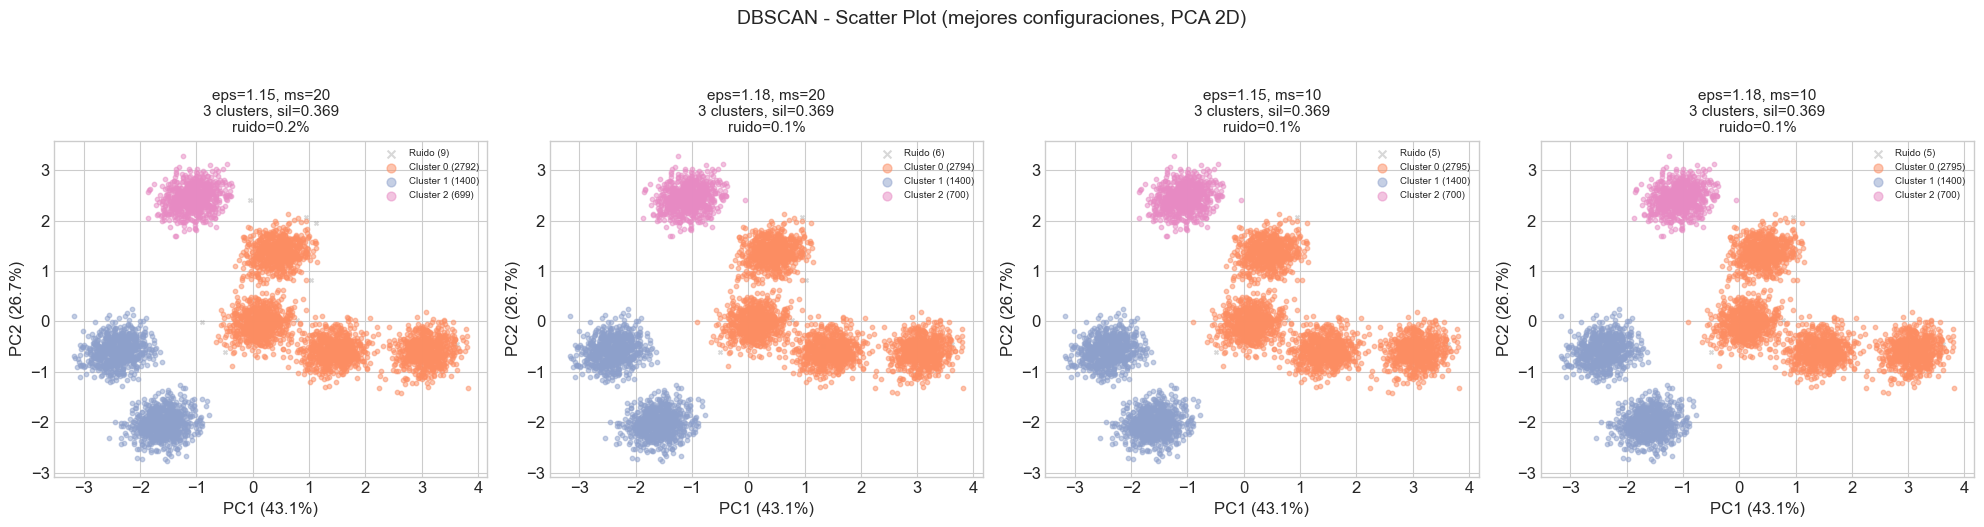

In [29]:
# DBSCAN: scatter plots de las mejores configuraciones
# Seleccionar top 4 configuraciones validas por silhouette
valid_results = [r for r in dbscan_results if r['n_clusters'] >= 2 and r['pct_noise'] < 50]
top_dbscan = sorted(valid_results, key=lambda r: r['silhouette'], reverse=True)[:4]

if len(top_dbscan) > 0:
    # Reusar la proyeccion PCA 2D del espacio escalado
    if 'X_pca_scaled' not in dir():
        pca_2d_scaled = PCA(n_components=2)
        X_pca_scaled = pca_2d_scaled.fit_transform(X_scaled.values)
        pca_var_scaled = pca_2d_scaled.explained_variance_ratio_
    
    n_plots = len(top_dbscan)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    
    for ax, res in zip(axes, top_dbscan):
        labels = res['labels']
        unique_labels = sorted(set(labels))
        palette_db = sns.color_palette('Set2', len(unique_labels))
        
        for i, cl in enumerate(unique_labels):
            mask = labels == cl
            if cl == -1:
                ax.scatter(X_pca_scaled[mask, 0], X_pca_scaled[mask, 1],
                           s=8, alpha=0.3, color='gray', label=f'Ruido ({mask.sum()})', marker='x')
            else:
                ax.scatter(X_pca_scaled[mask, 0], X_pca_scaled[mask, 1],
                           s=10, alpha=0.5, label=f'Cluster {cl} ({mask.sum()})', color=palette_db[i])
        
        ax.set_title(f'eps={res["eps"]}, ms={res["min_samples"]}\n'
                     f'{res["n_clusters"]} clusters, sil={res["silhouette"]:.3f}\n'
                     f'ruido={res["pct_noise"]:.1f}%', fontsize=11)
        ax.set_xlabel(f'PC1 ({pca_var_scaled[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({pca_var_scaled[1]*100:.1f}%)')
        ax.legend(fontsize=7, markerscale=2)
    
    plt.suptitle('DBSCAN - Scatter Plot (mejores configuraciones, PCA 2D)', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron configuraciones DBSCAN validas para scatter plot.")

---
## 4. Comparativa de metodos y seleccion

Comparamos los mejores resultados de cada metodo para elegir el mas adecuado.

In [30]:
# ============================================================
# Comparativa: mejor resultado de cada metodo
# ============================================================
best_k_hier = max(hier_scores, key=lambda k: hier_scores[k]['silhouette'])
hier_best = hier_scores[best_k_hier]

# Mejor config DBSCAN
best_dbscan = max(
    [r for r in dbscan_results if r['n_clusters'] >= 2 and r['pct_noise'] < 50],
    key=lambda r: r['silhouette'],
    default=None
)

# KModes: mejor k (ya calculado antes)
best_k_kmodes = max(kmodes_silhouettes, key=kmodes_silhouettes.get)

print("=" * 70)
print("COMPARATIVA DE METODOS")
print("=" * 70)

print(f"\n--- KModes (mejor k={best_k_kmodes}) ---")
print(f"    Coste: {kmodes_models[best_k_kmodes][0].cost_:.0f}")
print(f"    Silhouette (Hamming): {kmodes_silhouettes[best_k_kmodes]:.4f}")
_, km_labels = kmodes_models[best_k_kmodes]
print(f"    Distribucion: {dict(zip(*np.unique(km_labels, return_counts=True)))}")

print(f"\n--- Jerarquico (mejor k={best_k_hier}) ---")
print(f"    Silhouette: {hier_best['silhouette']:.4f}")
print(f"    Calinski-Harabasz: {hier_best['calinski_harabasz']:.1f}")
print(f"    Davies-Bouldin: {hier_best['davies_bouldin']:.4f}")
print(f"    Distribucion: {dict(zip(*np.unique(hier_best['labels'], return_counts=True)))}")

if best_dbscan:
    print(f"\n--- DBSCAN (eps={best_dbscan['eps']}, min_samples={best_dbscan['min_samples']}) ---")
    print(f"    Clusters: {best_dbscan['n_clusters']}")
    print(f"    Silhouette: {best_dbscan['silhouette']:.4f}")
    print(f"    Ruido: {best_dbscan['n_noise']} puntos ({best_dbscan['pct_noise']:.1f}%)")
    db_labels = best_dbscan['labels']
    print(f"    Distribucion: {dict(zip(*np.unique(db_labels, return_counts=True)))}")
else:
    print("\n--- DBSCAN: no encontro configuracion valida con >=2 clusters y <50% ruido ---")

print("\n" + "=" * 70)

COMPARATIVA DE METODOS

--- KModes (mejor k=5) ---
    Coste: 21252
    Silhouette (Hamming): 0.3772
    Distribucion: {np.uint16(0): np.int64(1189), np.uint16(1): np.int64(739), np.uint16(2): np.int64(1421), np.uint16(3): np.int64(695), np.uint16(4): np.int64(856)}

--- Jerarquico (mejor k=4) ---
    Silhouette: 0.3708
    Calinski-Harabasz: 2723.6
    Davies-Bouldin: 1.0196
    Distribucion: {np.int64(0): np.int64(2100), np.int64(1): np.int64(1400), np.int64(2): np.int64(700), np.int64(3): np.int64(700)}

--- DBSCAN (eps=1.15, min_samples=20) ---
    Clusters: 3
    Silhouette: 0.3695
    Ruido: 9 puntos (0.2%)
    Distribucion: {np.int64(-1): np.int64(9), np.int64(0): np.int64(2792), np.int64(1): np.int64(1400), np.int64(2): np.int64(699)}



### Seleccion del metodo

Tras revisar los resultados de arriba, elige el metodo y k que mejor equilibre:
1. **Silhouette alto** (clusters bien separados)
2. **Distribucion equilibrada** (no hay un cluster gigante y otros minusculos)
3. **Interpretabilidad** (un numero de clusters manejable, 3-5 tipicamente)

Ajusta `METODO_ELEGIDO` y `K_ELEGIDO` en la siguiente celda segun tu analisis.

In [38]:
# =============================================
# AJUSTAR SEGUN RESULTADOS DE ARRIBA
# =============================================
METODO_ELEGIDO = 'kmodes'   # opciones: 'kmodes', 'jerarquico', 'dbscan'
K_ELEGIDO = 5               # ajustar segun graficas

# Obtener labels del metodo elegido
if METODO_ELEGIDO == 'kmodes':
    _, final_labels = kmodes_models[K_ELEGIDO]
elif METODO_ELEGIDO == 'jerarquico':
    hc_final = AgglomerativeClustering(n_clusters=K_ELEGIDO, linkage='ward')
    final_labels = hc_final.fit_predict(X_scaled.values)
elif METODO_ELEGIDO == 'dbscan':
    # Usa la mejor configuracion DBSCAN encontrada
    final_labels = best_dbscan['labels']
    K_ELEGIDO = best_dbscan['n_clusters']

df['cluster'] = final_labels
df_cat['cluster'] = final_labels

print(f"Metodo elegido: {METODO_ELEGIDO} con k={K_ELEGIDO}")
print(f"\nDistribucion de clusters:")
print(df['cluster'].value_counts().sort_index())

Metodo elegido: kmodes con k=5

Distribucion de clusters:
cluster
0    1189
1     739
2    1421
3     695
4     856
Name: count, dtype: int64


---
## 5. Analisis cuantitativo de los clusters

Estadisticas descriptivas de cada cluster sobre las variables numericas originales.

In [39]:
# Media de cada variable numerica por cluster
cluster_means = df.groupby('cluster')[num_cols].mean().round(2)
print("Media por cluster (variables numericas originales):\n")
print(cluster_means.to_string())

# Tamano de cada cluster
print(f"\nTamano de clusters:")
print(df['cluster'].value_counts().sort_index().to_string())

Media por cluster (variables numericas originales):

         tenure_years    age  salary_k  performance_score  absenteeism_days  workload_index
cluster                                                                                    
0               10.34  48.85     90.76              82.89              1.34            7.75
1                5.21  38.35     39.36              28.30             11.51            6.97
2                1.17  23.69     37.14              70.02              2.16            4.05
3               11.00  48.01     62.08              35.34              6.00            3.93
4                6.57  40.76     62.73              66.84              3.53            6.02

Tamano de clusters:
cluster
0    1189
1     739
2    1421
3     695
4     856


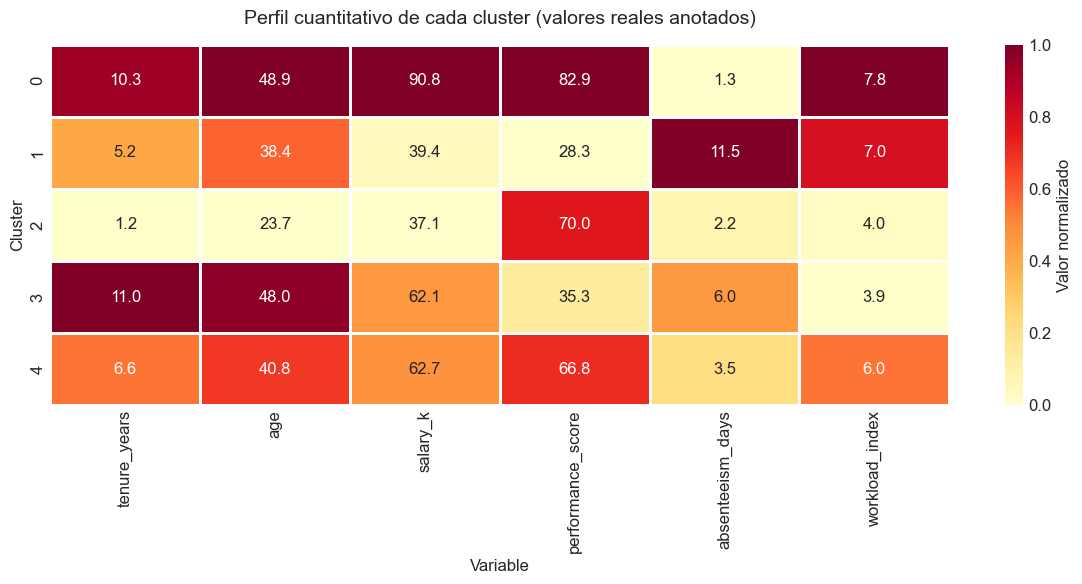

In [40]:
# Heatmap de medias normalizadas por cluster (para comparar visualmente)
cluster_means_norm = df.groupby('cluster')[num_cols].mean()
# Normalizar por columna para que el color sea comparable entre variables
from sklearn.preprocessing import MinMaxScaler
scaler_vis = MinMaxScaler()
cluster_means_norm_vals = pd.DataFrame(
    scaler_vis.fit_transform(cluster_means_norm),
    index=cluster_means_norm.index,
    columns=cluster_means_norm.columns
)

fig, ax = plt.subplots(figsize=(12, max(4, K_ELEGIDO * 1.2)))
sns.heatmap(cluster_means_norm_vals, annot=cluster_means.values, fmt='.1f',
            cmap='YlOrRd', linewidths=1, ax=ax, cbar_kws={'label': 'Valor normalizado'})
ax.set_title('Perfil cuantitativo de cada cluster (valores reales anotados)', fontsize=14, pad=15)
ax.set_xlabel('Variable')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

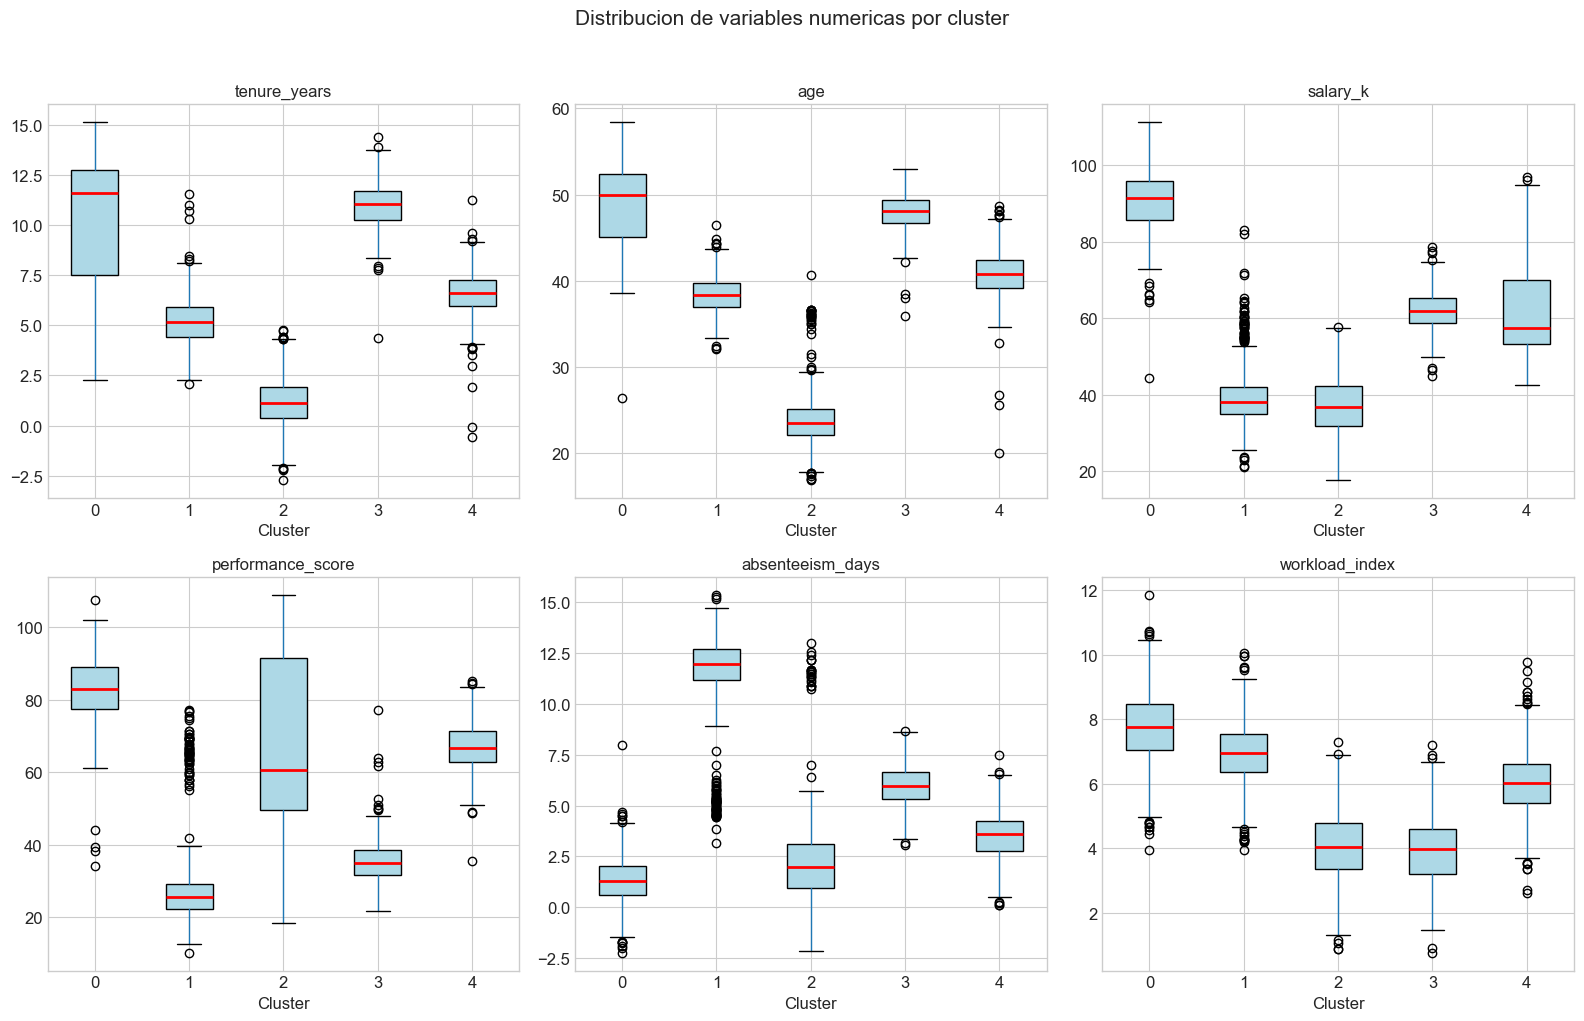

In [41]:
# Boxplots de cada variable numerica por cluster
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = sns.color_palette('Set2', K_ELEGIDO)

for i, col in enumerate(num_cols):
    ax = axes[i]
    df.boxplot(column=col, by='cluster', ax=ax, patch_artist=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('')

plt.suptitle('Distribucion de variables numericas por cluster', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Analisis cualitativo de los clusters

Composicion de cada cluster segun las variables categoricas (originales y niveles categorizados). Esto nos permite construir perfiles de negocio interpretables.


Department (% por cluster):
Department  Finance    HR    IT  Marketing  Sales
cluster                                          
0              20.0  19.1  19.3       18.9   22.6
1              20.0  21.4  19.4       21.1   18.1
2              18.0  20.2  20.6       19.5   21.7
3              19.1  19.3  19.1       23.7   18.7
4              21.1  19.6  19.9       19.0   20.3


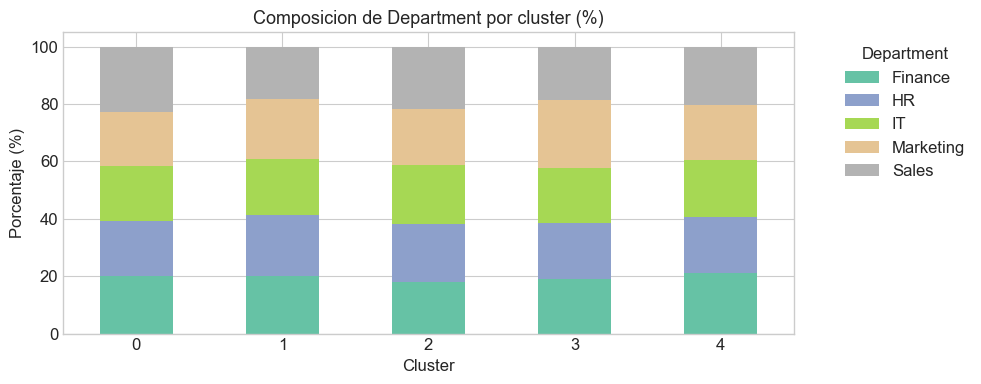


Education_Level (% por cluster):
Education_Level  Bachelor  High School  Master   PhD
cluster                                             
0                    23.9         24.6    25.2  26.3
1                    25.7         26.9    22.9  24.5
2                    25.0         24.3    24.4  26.3
3                    23.6         26.9    25.5  24.0
4                    24.2         23.9    28.3  23.6


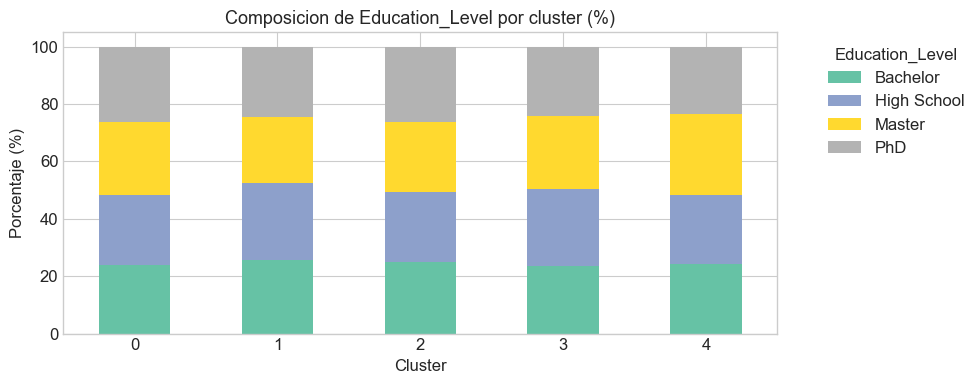

In [42]:
# Distribucion de variables categoricas originales por cluster
for col in cat_cols:
    ct = pd.crosstab(df['cluster'], df[col], normalize='index') * 100
    print(f"\n{col} (% por cluster):")
    print(ct.round(1).to_string())
    
    fig, ax = plt.subplots(figsize=(10, 4))
    ct.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
    ax.set_title(f'Composicion de {col} por cluster (%)', fontsize=13)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Porcentaje (%)')
    ax.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()


tenure_years_nivel (% por cluster):
tenure_years_nivel  Bajo  Medio  Alto
cluster                              
0                    0.5   26.7  72.8
1                   24.1   73.7   2.2
2                   99.9    0.1   0.0
3                    0.1    0.0  99.9
4                    1.5   88.0  10.5


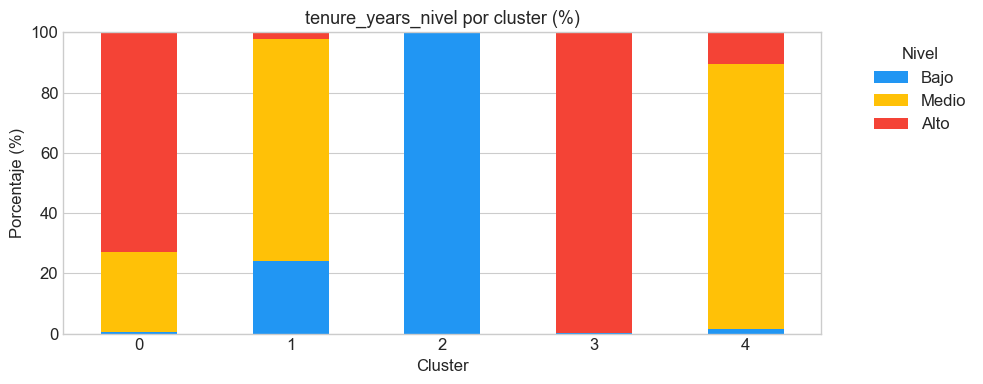


age_nivel (% por cluster):
age_nivel  Bajo  Medio  Alto
cluster                     
0           0.1   19.8  80.1
1          20.8   78.9   0.3
2          99.9    0.1   0.0
3           0.1    3.3  96.5
4           4.8   90.4   4.8


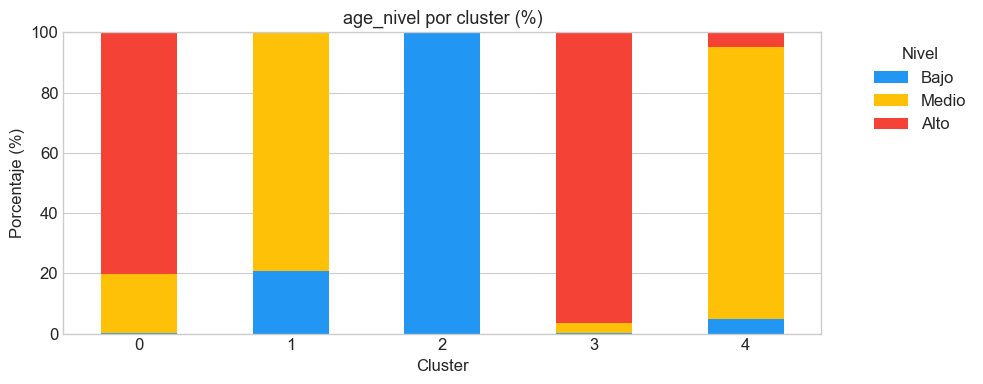


salary_k_nivel (% por cluster):
salary_k_nivel  Bajo  Medio  Alto
cluster                          
0                0.0    0.1  99.9
1               75.0   24.0   1.1
2               74.8   25.2   0.0
3                0.0   66.2  33.8
4                0.0   72.5  27.5


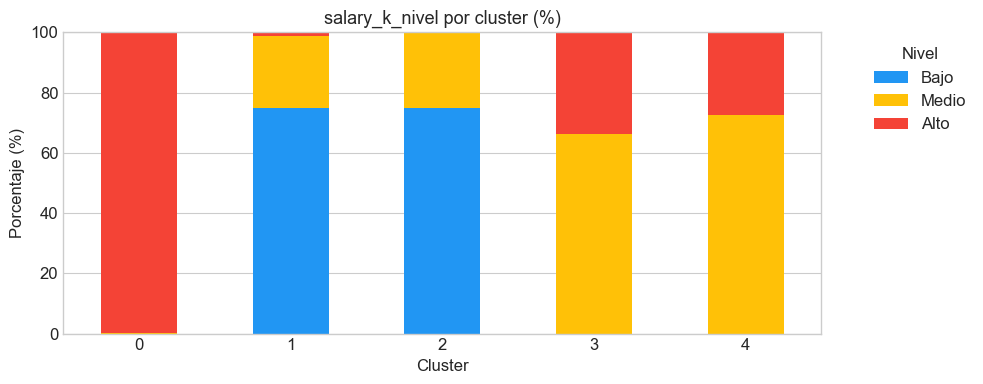


performance_score_nivel (% por cluster):
performance_score_nivel  Bajo  Medio  Alto
cluster                                   
0                         0.3   20.3  79.4
1                        92.2    7.4   0.4
2                        17.3   33.5  49.2
3                        98.6    1.3   0.1
4                         0.1   97.7   2.2


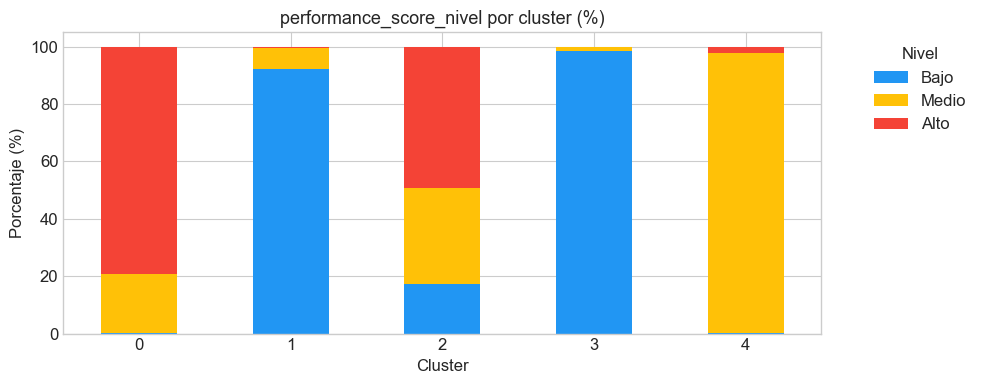


absenteeism_days_nivel (% por cluster):
absenteeism_days_nivel  Bajo  Medio  Alto
cluster                                  
0                       73.3   26.2   0.4
1                        0.0    0.3  99.7
2                       48.5   44.8   6.8
3                        0.0    4.9  95.1
4                        6.5   73.9  19.5


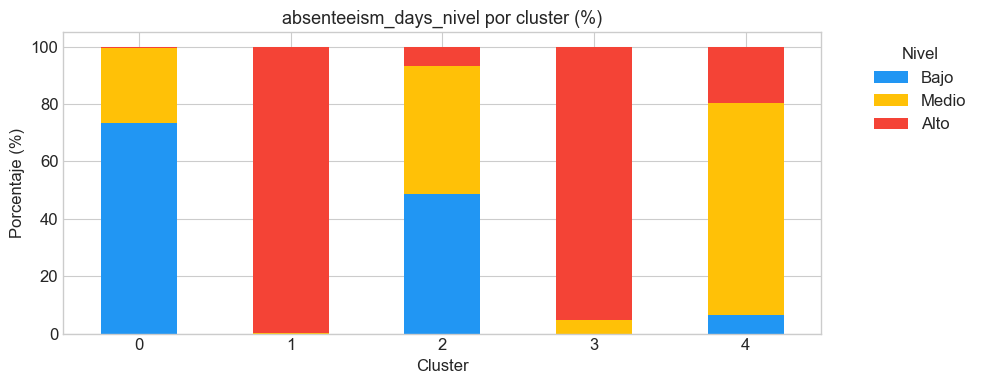


workload_index_nivel (% por cluster):
workload_index_nivel  Bajo  Medio  Alto
cluster                                
0                      0.3   14.7  85.0
1                      1.5   34.2  64.3
2                     71.0   28.8   0.2
3                     76.1   23.5   0.4
4                      7.6   72.1  20.3


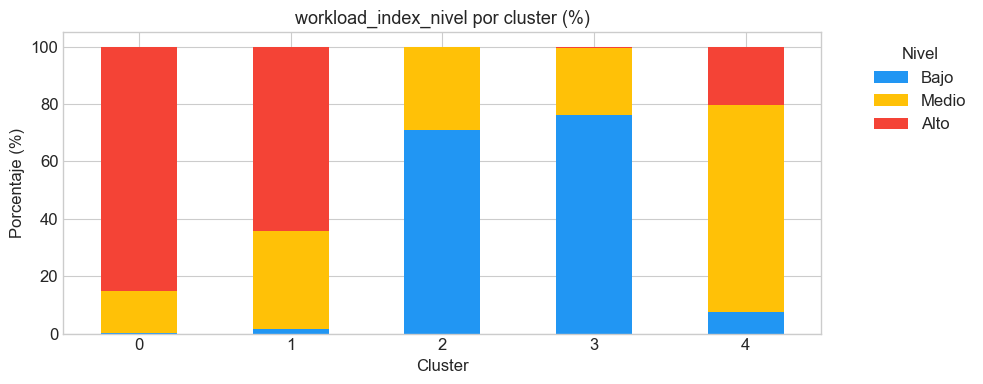

In [43]:
# Distribucion de variables categorizadas (niveles) por cluster
for col in cat_nivel_cols:
    ct = pd.crosstab(df_cat['cluster'], df_cat[col], normalize='index') * 100
    print(f"\n{col} (% por cluster):")
    print(ct.round(1).to_string())
    
    fig, ax = plt.subplots(figsize=(10, 4))
    colors_nivel = {'Bajo': '#2196F3', 'Medio': '#FFC107', 'Alto': '#F44336'}
    ct_ordered = ct[['Bajo', 'Medio', 'Alto']] if all(c in ct.columns for c in ['Bajo', 'Medio', 'Alto']) else ct
    ct_ordered.plot(kind='bar', stacked=True, ax=ax,
                    color=[colors_nivel.get(c, 'gray') for c in ct_ordered.columns])
    ax.set_title(f'{col} por cluster (%)', fontsize=13)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Porcentaje (%)')
    ax.legend(title='Nivel', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

---
## 7. Perfiles de negocio y recomendaciones

Resumen ejecutivo de cada cluster: perfil dominante, posible causa de fuga y accion recomendada.

In [44]:
# Resumen compacto de cada cluster: moda de categoricas + media de numericas
print("=" * 80)
print("PERFIL RESUMEN DE CADA CLUSTER")
print("=" * 80)

for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    mask_cat = df_cat['cluster'] == c
    n = mask.sum()
    
    print(f"\n--- Cluster {c} ({n} empleados, {n/len(df)*100:.1f}%) ---")
    
    # Medias numericas
    print("  Variables numericas (media):")
    for col in num_cols:
        val = df.loc[mask, col].mean()
        global_mean = df[col].mean()
        diff = ((val - global_mean) / global_mean) * 100
        arrow = "^" if diff > 10 else ("v" if diff < -10 else "~")
        print(f"    {col}: {val:.1f}  ({arrow} {diff:+.0f}% vs global)")
    
    # Modas categoricas
    print("  Variables categoricas (moda):")
    for col in cat_cols:
        moda = df.loc[mask, col].mode().iloc[0]
        pct = (df.loc[mask, col] == moda).mean() * 100
        print(f"    {col}: {moda} ({pct:.0f}%)")
    
    # Niveles dominantes
    print("  Niveles dominantes:")
    for col in cat_nivel_cols:
        moda = df_cat.loc[mask_cat, col].mode().iloc[0]
        pct = (df_cat.loc[mask_cat, col] == moda).mean() * 100
        print(f"    {col}: {moda} ({pct:.0f}%)")

print("\n" + "=" * 80)

PERFIL RESUMEN DE CADA CLUSTER

--- Cluster 0 (1189 empleados, 24.3%) ---
  Variables numericas (media):
    tenure_years: 10.3  (^ +63% vs global)
    age: 48.9  (^ +27% vs global)
    salary_k: 90.8  (^ +55% vs global)
    performance_score: 82.9  (^ +35% vs global)
    absenteeism_days: 1.3  (v -68% vs global)
    workload_index: 7.8  (^ +36% vs global)
  Variables categoricas (moda):
    Department: Sales (23%)
    Education_Level: PhD (26%)
  Niveles dominantes:
    tenure_years_nivel: Alto (73%)
    age_nivel: Alto (80%)
    salary_k_nivel: Alto (100%)
    performance_score_nivel: Alto (79%)
    absenteeism_days_nivel: Bajo (73%)
    workload_index_nivel: Alto (85%)

--- Cluster 1 (739 empleados, 15.1%) ---
  Variables numericas (media):
    tenure_years: 5.2  (v -18% vs global)
    age: 38.4  (~ -0% vs global)
    salary_k: 39.4  (v -33% vs global)
    performance_score: 28.3  (v -54% vs global)
    absenteeism_days: 11.5  (^ +177% vs global)
    workload_index: 7.0  (^ +22% vs 

### Interpretacion y plan de accion

Basandote en los perfiles anteriores, completa esta tabla para cada cluster:

| Cluster | Perfil | Posible causa de fuga | Riesgo | Accion recomendada |
|---------|--------|----------------------|--------|-------------------|
| 0 | ... | ... | Alto/Medio/Bajo | ... |
| 1 | ... | ... | Alto/Medio/Bajo | ... |
| ... | ... | ... | ... | ... |

**Guia de interpretacion:**
- Salario bajo + tenure bajo → riesgo de fuga por compensacion
- Performance alto + salario bajo → riesgo de fuga por falta de reconocimiento
- Workload alto + absentismo alto → riesgo de burnout
- Tenure alto + performance medio → empleado estable, bajo riesgo
- Absentismo alto generalizado → posible problema de clima laboral